In [120]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time
import os
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

# Projeto 3 de Algebra Linear Numérica

### 1. Redução à Forma de Hessenberg

**a) _Cálculo dos refletores_. Escreva uma função `to_hessemberg(A)` que calcula a forma de Hessemberg de uma matriz A usando refletores de Householder. A função deve retornar uma lista de refletores $v_i$, a matriz $H$ tal que $A = QHQ^∗$, e $Q$, que é a matriz ortogonal dada pelo produto dos refletores**

In [121]:
def sign(x):
    return -1 if x < 0 else 1

In [122]:
def to_hessenberg(A: np.ndarray) -> tuple[list[np.ndarray], np.ndarray, np.ndarray]:
    """Função que recebe uma matriz A e calcula sua forma de Hessenberg.

    Args:
        A (np.ndarray): Matriz que será calculada

    Returns:
        tuple[list[np.ndarray], np.ndarray, np.ndarray]: Lista contendo os vetores de reflexão v_i, a matriz de
        Hessenberg e a matriz ortogonal Q
    """
    if A.shape[0] != A.shape[1]:
        raise ValueError("Você precisa passar uma matriz quadrada")

    M = A.copy()

    reflectors = []
    m = M.shape[0]
    Q = np.identity(m)

    for k in range(m-2):
        x = M[k+1:m, k].reshape(-1, 1)
        v_k = sign(x[0]) * np.linalg.norm(x) * np.eye(x.shape[0], 1) + x
        v_k = v_k / np.linalg.norm(v_k)
        M[k+1:m, k:m] -= 2 * v_k @ (v_k.T @ M[k+1:m, k:m])
        M[0:m, k+1:m] -= 2 * (M[0:m, k+1:m] @ v_k) @ v_k.T

        Q[k+1:m, k+1:m] @= v_k @ v_k.T

        reflectors.append(v_k)    

    Q = np.eye(m)
    for k, v_k in enumerate(reflectors):
        H_k = np.eye(m)
        H_k[k + 1:m, k + 1:m] -= 2 * (v_k @ v_k.T)
        Q = Q @ H_k

    return reflectors, M, Q

**b\) Verifique que sua função de fato está correta, calculando $\|A −QHQ^∗\|$ e $\|Q^∗Q −I\|$ para diversas matrizes A: use simétricas e não simétricas, e de diferentes tamanhos**

In [123]:
normal_matrices = [np.random.random_sample((m, m)) for m in range(2, 100)]
matrices_to_symetrize = [np.random.random_sample((m, m)) for m in range(2, 100)]
symetric_matrices = []
for matrix in matrices_to_symetrize:
    m = (matrix + matrix.T)/2
    symetric_matrices.append(m)

In [124]:
normal_hessenbergs = [to_hessenberg(m) for m in normal_matrices]
symetric_hessenbergs = [to_hessenberg(m) for m in symetric_matrices]

In [125]:
norms_difference_normals = []
norms_difference_symetrics = []

identities_difference_normals = []
identities_difference_symetrics = []

for i in range(len(normal_hessenbergs)):
    # Adicionando das matrizes comuns
    norm_normal = np.linalg.norm(
        normal_matrices[i] - normal_hessenbergs[i][2] @ normal_hessenbergs[i][1] @ normal_hessenbergs[i][2].T
    )
    norms_difference_normals.append(norm_normal)

    # Adicionando das matrizes simétricas
    norm_symetric = np.linalg.norm(
        symetric_matrices[i] - symetric_hessenbergs[i][2] @ symetric_hessenbergs[i][1] @ symetric_hessenbergs[i][2].T
    )
    norms_difference_symetrics.append(norm_symetric)


    # Adicionando das matrizes comuns
    identity_difference_normal = np.linalg.norm(
        np.identity(i+2) - normal_hessenbergs[i][2].T @ normal_hessenbergs[i][2]
    )
    identities_difference_normals.append(identity_difference_normal)

    # Adicionando das matrizes simétricas
    identity_difference_symetric = np.linalg.norm(
        np.identity(i+2) - symetric_hessenbergs[i][2].T @ symetric_hessenbergs[i][2]
    )
    identities_difference_symetrics.append(identity_difference_symetric)

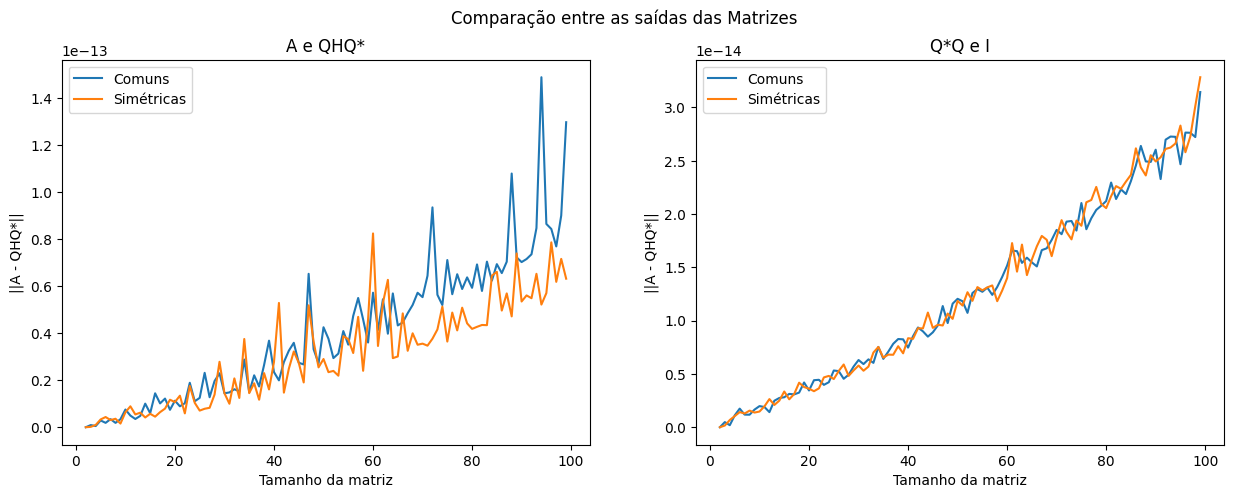

In [126]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

fig.suptitle("Comparação entre as saídas das Matrizes")

axes[0].set_title("A e QHQ*")
axes[1].set_title("Q*Q e I")

axes[0].plot(range(2, 100), norms_difference_normals, label="Comuns")
axes[0].plot(range(2, 100), norms_difference_symetrics, label="Simétricas")

axes[1].plot(range(2, 100), identities_difference_normals, label="Comuns")
axes[1].plot(range(2, 100), identities_difference_symetrics, label="Simétricas")

axes[0].set_xlabel("Tamanho da matriz")
axes[0].set_ylabel("||A - QHQ*||")
axes[1].set_xlabel("Tamanho da matriz")
axes[1].set_ylabel("||A - QHQ*||")

axes[0].legend()
axes[1].legend()
plt.show()

Aqui podemos ver que a função está retornando matrizes satisfatórias

**c) _Complexidade_. Realize testes para matrizes n ×n, com n variando de 10 até 1000 (ou mais, se o seu computador aguentar!). Quanto tempo seu algoritmo leva para calcular a forma de Hessemberg? Para matrizes pequenas, repita o teste até levar pelo menos 1 segundo, para evitar erros de medida de tempos muito pequenos. Qual parece ser a complexidade observada do algoritmo?**

O código abaixo faz o teste de execução da função `to_hessenberg` para matrizes indo de 10 até 1000 variando de 50 em 50 nos tamanhos. Esse código não deve ser executado caso junto do notebook tenha um arquivo chamado `hessenberg_execution_time.csv`, tendo em vista que ele armazena os resultados dessas funções para evitar a necessidade de executar e esperar as células terminarem a execução toda a vez que uma mudança for realizada

In [127]:
n = 1701
step = 50
times_file_exists = os.path.exists("hessenberg_execution_time.csv")

In [128]:
normal_times = []

def calculate_normal_matrix(size):
    matrix = np.random.random_sample((size, size))  # Gero a matriz
    initial = time.perf_counter()  # Inicio o contador de performance
    _, _, _ = to_hessenberg(matrix)  # Executo a função da matriz de hessenberg
    finish = time.perf_counter()  # Finalizo o contador

    performance = finish-initial

    return performance
    

if not times_file_exists:
    for i in range(10, n, step):
        normal_times.append(calculate_normal_matrix(i))

In [129]:
symmetric_times = []

def calculate_symetric_matrix(size):
    matrix = np.random.random_sample((size, size))
    matrix = (matrix + matrix.T) / 2
    initial = time.perf_counter()
    _, _, _ = to_hessenberg(matrix)
    finish = time.perf_counter()

    performance = finish-initial

    return performance


if not times_file_exists:
    for i in range(10, n, step):
        symmetric_times.append(calculate_symetric_matrix(i))

Aqui eu vou fazer uma regressão polinomial utilizando os valores dos tempos que obti. Eu vou fazer com valores de potências indo de 2 à 4, já que, se meu polinômio de complexidade fosse maior que isso, já seria um algoritmo impraticável. Porém, eu vou fazer a regressão linear utilizando apenas 80% dos tempos que eu tenho, de forma que eu consiga utilizar a outra parte para ter uma noção de qual polinômio é o correto a se utilizar

In [130]:
def apply_polynomial_to_space(sample: np.ndarray, coefficients: np.ndarray) -> np.array:
    """Function that receives a unidimensional Array (column array or common array), applies a polynomial function
    to it and returns the vector containing the results of the applied polynomial

    Args:
        sample (np.ndarray): Array containting the points that will be applied
        coefficients (np.ndarray): Coefficients of the polynomial in terms that each i entry will be applied in x^i

    Returns:
        np.ndarray: The vector containing each entry of the "sample" vector applied to the polynomial function
    """
    y_vector = np.zeros(sample.shape)

    for i, ci in enumerate(coefficients):
        y_vector += ci*(sample**i)
    
    return y_vector

In [131]:
if times_file_exists:
    times_df = pd.read_csv("hessenberg_execution_time.csv")

    normal_times = times_df["NORMAL_TIME"]
    symmetric_times = times_df["SYMMETRIC_TIME"]
    sizes = times_df["SIZE"]

In [135]:
models = []  # Onde vou adicionar os modelos para plotagem posterior
# X_tests = []  # Armazeno os valores de teste que utilizarei para a plotagem posterior

normal_times = np.array(normal_times)

for i in range(3):
    model = LinearRegression()
    
    x = np.array(range(10,n,step))
    
    poly = PolynomialFeatures(degree=i+2, include_bias=False)
    poly_features = poly.fit_transform(x.reshape(-1, 1))

    X_train, _, y_train, _ = train_test_split(poly_features, normal_times, train_size=.4)

    model.fit(X_train, y_train)
    
    models.append(model)

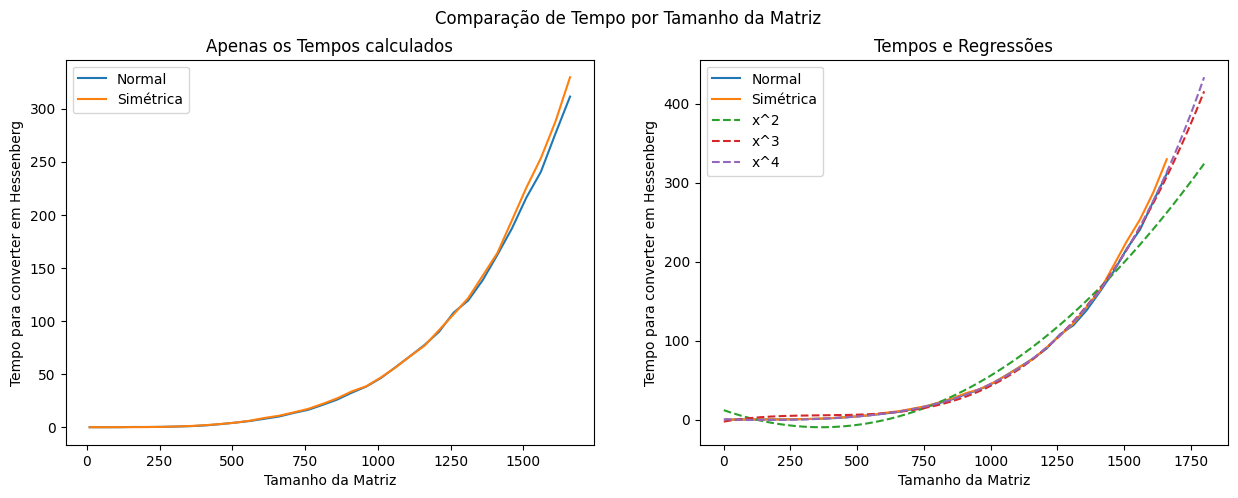

In [138]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

fig.suptitle("Comparação de Tempo por Tamanho da Matriz")
axes[0].plot(range(10,n,step), normal_times, label="Normal")
axes[0].plot(range(10,n,step), symmetric_times, label="Simétrica")
axes[1].plot(range(10,n,step), normal_times, label="Normal")
axes[1].plot(range(10,n,step), symmetric_times, label="Simétrica")

axes[0].set_title("Apenas os Tempos calculados")
axes[1].set_title("Tempos e Regressões")

x = np.linspace(0, 1800, 2002).reshape(-1, 1)

for j, model in enumerate(models):
    poly = PolynomialFeatures(degree=j+2, include_bias=False)
    poly_features = poly.fit_transform(x.reshape(-1, 1))
    y = model.predict(poly_features)
    axes[1].plot(x, y, "--", label=f"x^{j+2}")

axes[0].set_ylabel("Tempo para converter em Hessenberg")
axes[0].set_xlabel("Tamanho da Matriz")
axes[1].set_ylabel("Tempo para converter em Hessenberg")
axes[1].set_xlabel("Tamanho da Matriz")
axes[0].legend()
axes[1].legend()

plt.show()

In [134]:
if not times_file_exists:
    times_df = pd.DataFrame(columns=["NORMAL_TIME", "SYMMETRIC_TIME", "SIZE"])
    times_df["NORMAL_TIME"] = pd.Series(normal_times)
    times_df["SYMMETRIC_TIME"] = pd.Series(symmetric_times)
    times_df["SIZE"] = pd.Series(range(10,n,step))

    times_df.to_csv("hessenberg_execution_time.csv", index=False)

Fiz dois subplots para melhor visualização da curva e dos polinômios, já que a curva que originalmente representa o tempo das matrizes não simétricas ficou muito dificil de visualizar

Perceba que, no segundo gráfico, a curva verde ($x^2$) distoa bastante dos gráficos laranja e azul, então não faz sentido o algoritmo ser $O(n^2)$. No entanto o mesmo não pode ser dito das outras duas curvas